### Implementing simple Chatbot Using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import START, END, StateGraph

from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cache_write_tokens': None, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_541568ae70', 'id': 'chatcmpl-ECTVU2uKsfroS9uHvGyCW2C46pBCA', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019ffc2a-6909-70d0-abd3-a6d5f7f424f0-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [6]:
from langchain_groq import ChatGroq

llm_groq=ChatGroq(model="qwen/qwen3.6-27b")
llm_groq.invoke("Hey I am Krish and i like to play cricket")

AIMessage(content="\n<think>\nHere's a thinking process:\n\n1.  **Analyze User Input:**\n   - **Name:** Krish\n   - **Interest:** Likes to play cricket\n   - **Tone:** Casual, friendly introduction\n\n2.  **Identify Key Elements to Address:**\n   - Acknowledge the name (Krish)\n   - Acknowledge the interest (cricket)\n   - Respond in a friendly, engaging manner\n   - Ask follow-up questions to keep the conversation going\n   - Optionally share relevant cricket-related topics/questions\n\n3.  **Determine Response Goals:**\n   - Be welcoming and personalized\n   - Show enthusiasm for cricket\n   - Ask meaningful questions about their cricket experience/preferences\n   - Keep it open-ended for continued conversation\n\n4.  **Draft Response (Mental Refinement):**\n   Hey Krish! Nice to meet you. Cricket’s an amazing sport—there’s something special about the sound of leather on willow and the thrill of a last-over finish. 😄  \n   What position do you usually play? Are you more of a batter, 

### We Will start With Creating Nodes

In [7]:
from langgraph.checkpoint.memory import MemorySaver
memory=MemorySaver()

def superbot(state: State):
    return {"messages": [llm_groq.invoke(state["messages"])]}

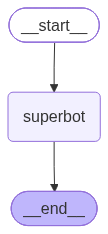

In [9]:
graph = StateGraph(State)

#node
graph.add_node("superbot", superbot)
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

graph_builder = graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [10]:
#config & Inovcation
config = {"configurable": {"thread_id": 1}}

graph_builder.invoke({"messages": "Hi my name is anand I like to play chess"}, config=config)

{'messages': [HumanMessage(content='Hi my name is anand I like to play chess', additional_kwargs={}, response_metadata={}, id='81bcaef6-e274-42a7-a4e4-0585394d39e4'),
  AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - Name: Anand\n   - Interest: Likes to play chess\n   - Greeting: "Hi my name is anand I like to play chess"\n\n2.  **Identify Key Elements:**\n   - Personal greeting/name sharing\n   - Hobby/interest declaration (chess)\n   - Implicit expectation: Acknowledge, respond warmly, possibly engage about chess\n\n3.  **Determine Response Goals:**\n   - Acknowledge the name warmly\n   - Show enthusiasm about chess\n   - Ask engaging follow-up questions to keep conversation going\n   - Offer relevant help/discussion points about chess\n   - Keep tone friendly and conversational\n\n4.  **Draft - Mental Refinement:**\n   Hi Anand! Nice to meet you. Chess is a fantastic game—it really sharpens strategy, patience, and problem-solving. How l

### Streaming 
Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.



#### Streaming The Responses With Stream Method

In [17]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({"messages": "Hi this is Anand I like to play chess"}, config, stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi this is Anand I like to play chess"\n   - This is a repetition of a previous message (they said this exact same thing earlier in the conversation).\n   - I already responded to it with a detailed chess-focused prompt asking about their level, preferences, and how I can help.\n   - They also mentioned liking football in the previous turn, and I acknowledged that while connecting it to chess.\n\n2.  **Identify Key Issues/Patterns:**\n   - The user is repeating the same message ("Hi this is Anand I like to play chess") multiple times.\n   - This could be due to:\n     - Technical glitch/repeat send\n     - Testing my consistency\n     - Not seeing/remembering previous responses\n     - Intentional repetition for emphasis\n   - I need to acknowledge the repetition politely, confirm I remember their interest, and gently steer the conversation forward witho

In [18]:
for chunk in graph_builder.stream({'messages':"I also like football"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi this is Anand I like to play photo', additional_kwargs={}, response_metadata={}, id='ffebadad-0e56-4848-98e5-f1f6019cd9a3'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi this is Anand I like to play photo"\n   - Key elements: \n     - Name: Anand\n     - Interest: "play photo" - This is likely a typo or misphrasing. Probably means "take photos", "photography", "edit photos", or maybe "play with photos" (like photo apps/games). Given common phrasing, "photography" is the most likely intended meaning.\n   - Tone: Friendly, introductory\n\n2.  **Identify Core Intent:**\n   - User is introducing themselves and sharing an interest.\n   - They likely want to connect, get advice, discuss photography, or explore photo-related topics.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the introduction warmly\n   - Clarify/interpret "play photo" politely (assume photography but leave ro

In [19]:
for chunk in graph_builder.stream({'messages':"I also like football "},config,stream_mode="updates"):
    print(chunk)

{'superbot': {'messages': [AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "I also like football"\n   - This is the 3rd time they\'ve said this exact phrase (or very similar).\n   - Previous context: They introduced themselves as Anand, said they like chess, and now keep repeating "I also like football".\n   - I\'ve already asked clarifying questions multiple times (playing vs watching, soccer vs American football, level, position, goals, etc.)\n   - The user isn\'t providing more details, just repeating the same statement.\n\n2.  **Identify the Core Issue:**\n   - The user might be testing the AI, has a very simple communication style, or expects me to just acknowledge it and move forward without asking more questions.\n   - Repeating the same prompt suggests they want a straightforward, engaging response that validates their interest and offers immediate value without overwhelming them with questions.\n\n3.  **Determine Respon

In [20]:
for chunk in graph_builder.stream({'messages':"I Love sports "},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi this is Anand I like to play photo', additional_kwargs={}, response_metadata={}, id='ffebadad-0e56-4848-98e5-f1f6019cd9a3'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi this is Anand I like to play photo"\n   - Key elements: \n     - Name: Anand\n     - Interest: "play photo" - This is likely a typo or misphrasing. Probably means "take photos", "photography", "edit photos", or maybe "play with photos" (like photo apps/games). Given common phrasing, "photography" is the most likely intended meaning.\n   - Tone: Friendly, introductory\n\n2.  **Identify Core Intent:**\n   - User is introducing themselves and sharing an interest.\n   - They likely want to connect, get advice, discuss photography, or explore photo-related topics.\n\n3.  **Determine Response Strategy:**\n   - Acknowledge the introduction warmly\n   - Clarify/interpret "play photo" politely (assume photography but leave ro

#### Streaming The Responses With astream Method

**Streaming tokens**
We often want to stream more than graph state.

In particular, with chat model calls it is common to stream the **tokens** as they are generated.

We can do this using the .astream_events method, which streams back events as they happen inside nodes!

Each event is a dict with a few keys:

- event: This is the type of event that is being emitted.
- name: This is the name of event.
- data: This is the data associated with the event.
- metadata: Containslanggraph_node, the node emitting the event.

In [21]:
config = {"configurable": {"thread_id": "3"}}

async for event in graph_builder.astream_events({"messages":["Hi My name is Krish and I like to play cricket"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi My name is Krish and I like to play cricket']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '019ffc39-9651-74f2-b36f-f97fce9e7d33', 'metadata': {'thread_id': '3', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi this is Anand I like to play photo', additional_kwargs={}, response_metadata={}, id='ffebadad-0e56-4848-98e5-f1f6019cd9a3'), AIMessage(content='\n<think>\nHere\'s a thinking process:\n\n1.  **Analyze User Input:**\n   - User says: "Hi this is Anand I like to play photo"\n   - Key elements: \n     - Name: Anand\n     - Interest: "play photo" - This is likely a typo or misphrasing. Probably means "take photos", "photography", "edit photos", or maybe "play with photos" (like photo apps/games). Given common phrasing, "photography" is the most likely intended meaning.\n   - Tone: Friendly, introductory\n\n2.  **Identify Core Intent:**\